# 24/04/2026

In [2]:
import pandas as pd

In [3]:
df=pd.read_csv("cleaned_GlobalWeatherRepository.csv")

# DATA VISUALIZATION

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df

,country,location_name,latitude,longitude,timezone,last_updated,temperature_celsius,condition_text,wind_kph,wind_degree,...,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,year,month,hour,continent,city
0,Afghanistan,Kabul,34.5200,69.1800,Asia/Kabul,2024-05-16 13:15:00,26.6,Partly Cloudy,13.3,338,...,0.20,8.40,26.60,1,1,2024,5,13,Asia,Kabul
1,Albania,Tirana,41.3300,19.8200,Europe/Tirane,2024-05-16 10:45:00,19.0,Partly cloudy,11.2,320,...,0.10,1.10,2.00,1,1,2024,5,10,Europe,Tirane
2,Algeria,Algiers,36.7600,3.0500,Africa/Algiers,2024-05-16 09:45:00,23.0,Sunny,15.1,280,...,13.40,10.40,18.40,1,1,2024,5,9,Africa,Algiers
3,Andorra,Andorra La Vella,42.5000,1.5200,Europe/Andorra,2024-05-16 10:45:00,6.3,Light drizzle,11.9,215,...,0.20,0.70,0.90,1,1,2024,5,10,Europe,Andorra
4,Angola,Luanda,-8.8400,13.2300,Africa/Luanda,2024-05-16 09:45:00,26.0,Partly cloudy,13.0,150,...,31.50,183.40,262.30,5,10,2024,5,9,Africa,Luanda
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
135057,Venezuela,Caracas,10.5000,-66.9167,America/Caracas,2026-04-12 02:30:00,19.1,Partly Cloudy,3.6,178,...,2.35,16.35,18.15,2,2,2026,4,2,America,Caracas
135058,Vietnam,Hanoi,21.0333,105.8500,Asia/Bangkok,2026-04-12 13:30:00,34.2,Sunny,11.2,245,...,17.85,61.15,64.45,3,8,2026,4,13,Asia,Bangkok
135059,Yemen,Sanaa,15.3547,44.2067,Asia/Aden,2026-04-12 09:30:00,19.3,Sunny,6.5,217,...,1.35,7.45,15.35,1,1,2026,4,9,Asia,Aden
135060,Zambia,Lusaka,-15.4167,28.2833,Africa/Lusaka,2026-04-12 08:30:00,18.5,Sunny,13.7,90,...,1.85,5.45,6.15,1,1,2026,4,8,Africa,Lusaka


### Global Temperature Distribution

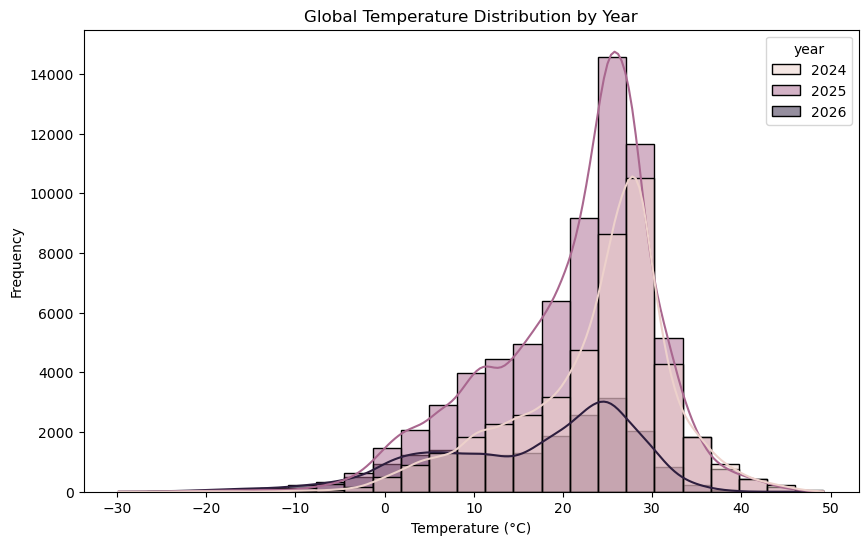

In [6]:
df.columns = df.columns.str.strip()

plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="temperature_celsius",
    hue="year",
    bins=25,
    kde=True
)

plt.xlabel('Temperature (°C)')
plt.ylabel('Frequency')
plt.title('Global Temperature Distribution by Year')

plt.show()

- The graph shows how global temperature distribution varies across different years, helping to compare changes and identify overall trends.

### High temperature of top 10 contries

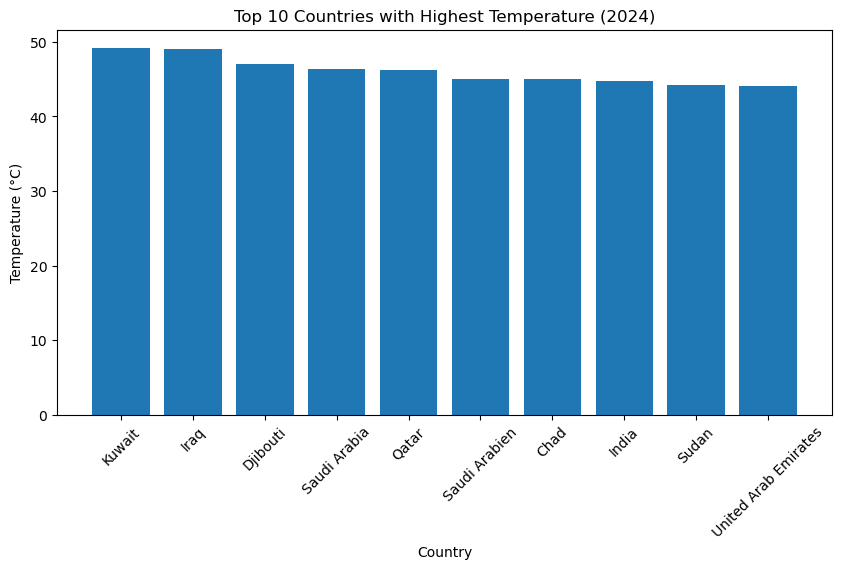

In [7]:
df_2024 = df[df["year"] == 2024]
country_temp = df_2024.groupby('country')['temperature_celsius'].max()
top10 = country_temp.sort_values(ascending=False).head(10)
plt.figure(figsize=(10,5))
plt.bar(top10.index, top10.values)

plt.xticks(rotation=45)
plt.xlabel('Country')
plt.ylabel('Temperature (°C)')
plt.title('Top 10 Countries with Highest Temperature (2024)')

plt.show()


- The chart shows the top 10 hottest countries with temperature ranging about 45°C to 50°C.
- All countries have very high temperature ,with only  small diffrence between them.

### Temperature vs Humidity

In [8]:
gf=df.loc[:10]

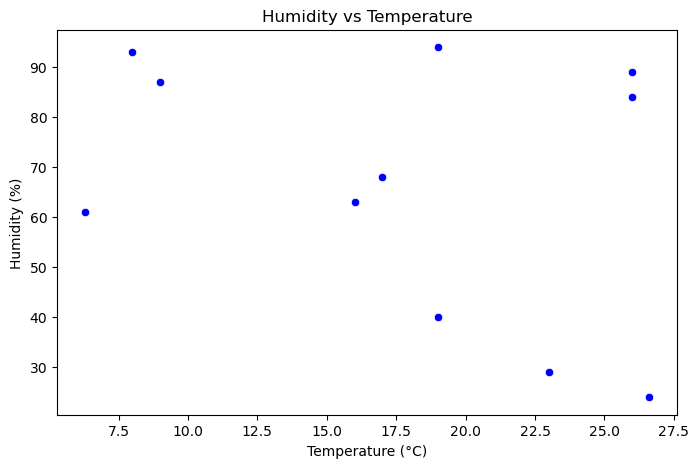

In [9]:
plt.figure(figsize=(8,5))

sns.scatterplot(x=gf["temperature_celsius"], y=gf["humidity"], color="Blue")

plt.title("Humidity vs Temperature")
plt.xlabel("Temperature (°C)")
plt.ylabel("Humidity (%)")

plt.show()

- The graph shows the relationship between temperature and humidity. As temperature increases, humidity tends to decreases.It helps to observe patterns or trends, such as whether humidity increases or decreases with temperature.


### Weather Condition Count

- The graph shows the most common weather condition.
- A few conditions have high count, while others are less common.

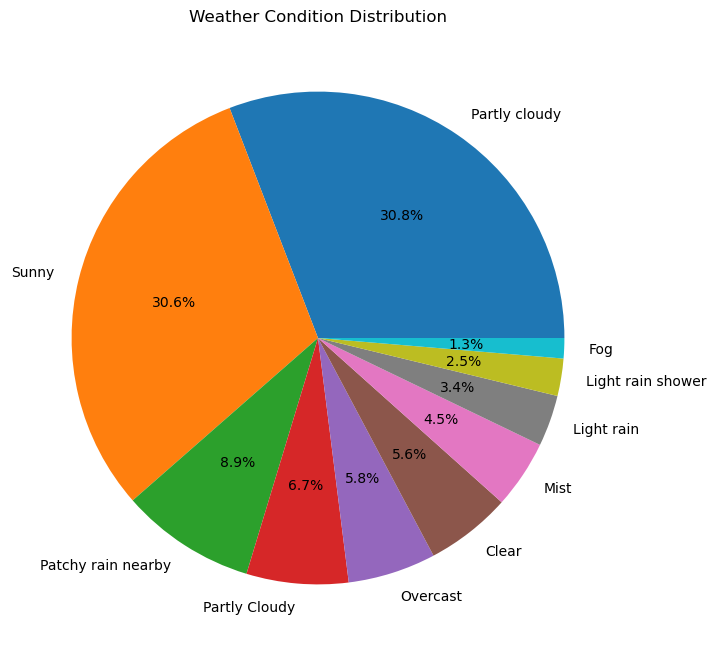

In [10]:
data = df['condition_text'].value_counts().head(10)

plt.figure(figsize=(8,8))

plt.pie(
    data.values,
    labels=data.index,
    autopct='%1.1f%%'
)

plt.title('Weather Condition Distribution')

plt.show()

- This pie chart shows the proportion of different weather conditions, helping to understand which conditions occur most frequently.

### Average Air Quality

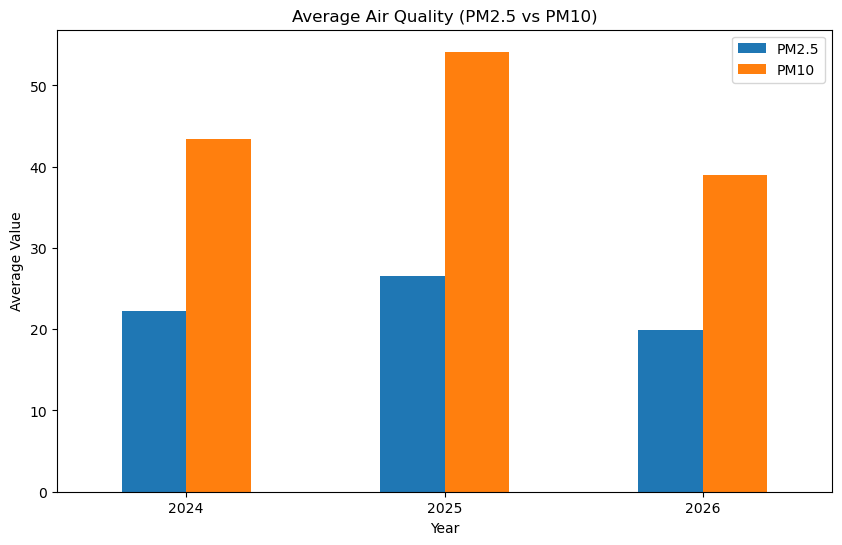

In [11]:
year_avg = df.groupby("year")[["air_quality_PM2.5", "air_quality_PM10"]].mean()


year_avg.plot(kind="bar", figsize=(10,6))

plt.title("Average Air Quality (PM2.5 vs PM10)")
plt.xlabel("Year")
plt.ylabel("Average Value")

plt.xticks(rotation=0)
plt.legend(["PM2.5", "PM10"])

plt.show()

- This graph shows how average PM2.5 and PM10 levels change across different years, helping to compare air pollution trends over time.

### 25/04/2026

### Global Air Pollution

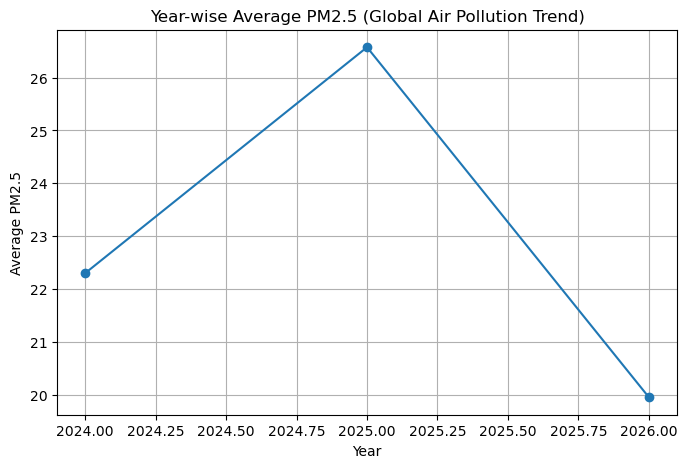

In [12]:
# Convert date column to datetime
df['last_updated'] = pd.to_datetime(df['last_updated'])

# Extract year
df['year'] = df['last_updated'].dt.year

# Group by year and get average PM2.5
yearly_data = df.groupby('year')['air_quality_PM2.5'].mean()

# Line chart
plt.figure(figsize=(8,5))
plt.plot(yearly_data.index, yearly_data.values, marker='o')

plt.title("Year-wise Average PM2.5 (Global Air Pollution Trend)")
plt.xlabel("Year")
plt.ylabel("Average PM2.5")

plt.grid(True)
plt.show()

- The line chart shows how average PM2.5 levels change over different years.
An upward trend indicates increasing air pollution, while a downward trend shows improvement in air quality.


### Highest Temperature by continent

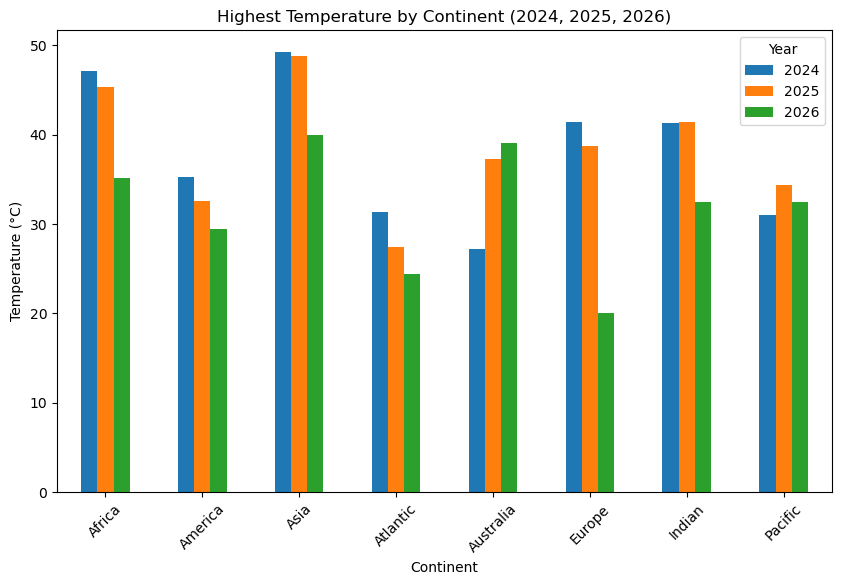

In [13]:
df_filtered = df[df["year"].isin([2024, 2025, 2026])]

# Group data
data = df_filtered.groupby(["continent", "year"])["temperature_celsius"].max().unstack()

# Plot
data.plot(kind="bar", figsize=(10,6))

plt.title("Highest Temperature by Continent (2024, 2025, 2026)")
plt.xlabel("Continent")
plt.ylabel("Temperature (°C)")

plt.xticks(rotation=45)
plt.legend(title="Year")

plt.show()

- The graph shows the **highest temperature recorded in each continent**.
Some continents have **very high temperatures**, indicating hotter climate regions.


### Top 10 Countries by Average Humidity

<Figure size 2000x1000 with 0 Axes>

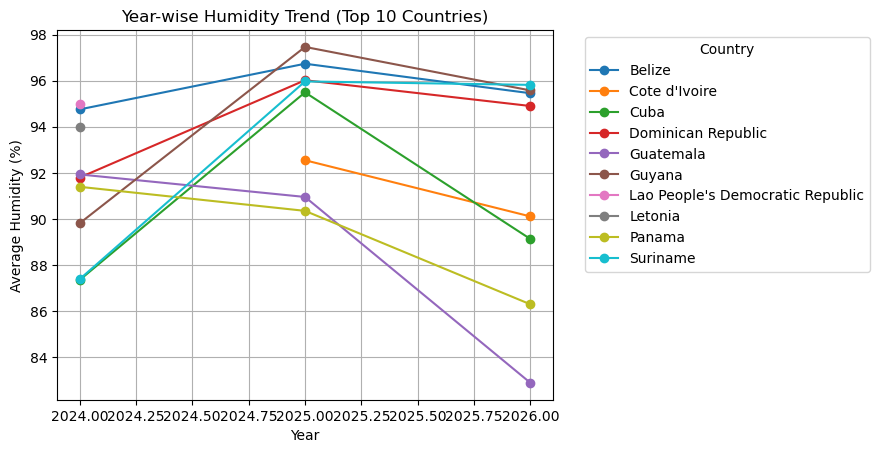

In [14]:
# Convert date column
df['last_updated'] = pd.to_datetime(df['last_updated'])

# Extract year
df['year'] = df['last_updated'].dt.year

# Get top 10 countries by overall humidity
top10 = df.groupby("country")["humidity"].mean().sort_values(ascending=False).head(10).index

# Filter only those countries
filtered_df = df[df['country'].isin(top10)]

# Group by year and country
yearly_data = filtered_df.groupby(['year', 'country'])['humidity'].mean().unstack()

# Line chart
plt.figure(figsize=(20,10))
yearly_data.plot(marker='o')

plt.title("Year-wise Humidity Trend (Top 10 Countries)")
plt.xlabel("Year")
plt.ylabel("Average Humidity (%)")

plt.grid(True)
plt.legend(title="Country", bbox_to_anchor=(1.05,1))
plt.show()

- This chart shows how humidity changes each year in top 10 countries.
If the line goes up → humidity increases, if it goes down → humidity decreases.

### Temperature Distribution in India

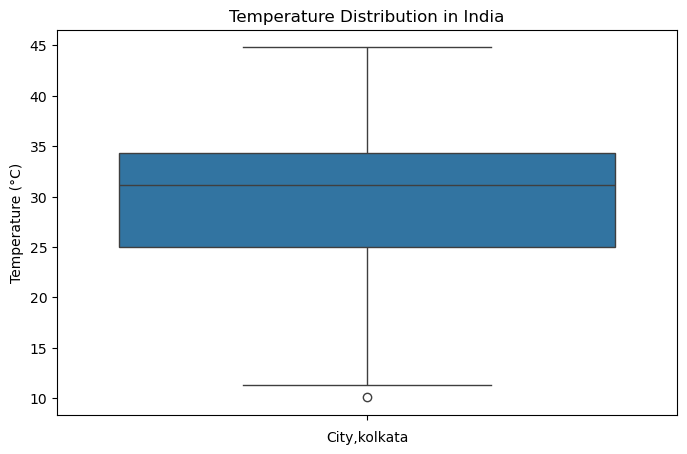

In [15]:
# Clean column names
df.columns = df.columns.str.strip()

# Filter only India
india_df = df[df["country"] == "India"]

# Box plot
plt.figure(figsize=(8,5))

sns.boxplot(
    data=india_df,
    y="temperature_celsius"
)

plt.title("Temperature Distribution in India")
plt.xlabel("City,kolkata")
plt.ylabel("Temperature (°C)")

plt.show()

- This box plot shows the distribution of temperature in India, highlighting the median, variation, and extreme values (outliers). It helps understand overall temperature patterns

### Average Wind Speed Per Month

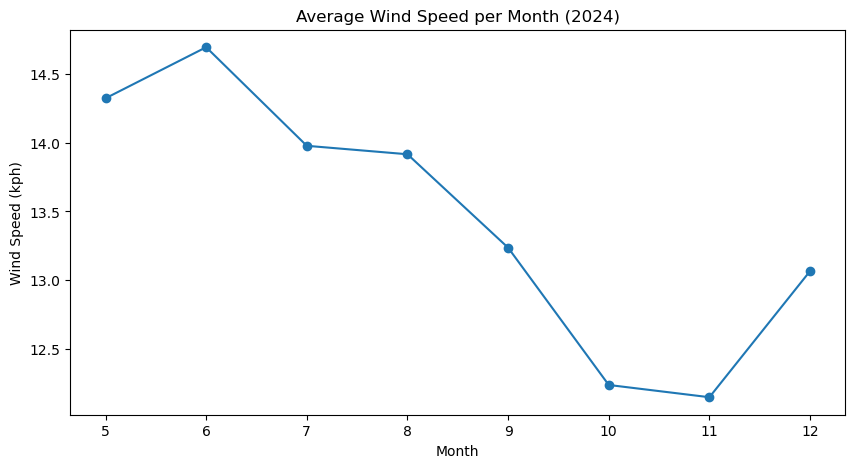

In [16]:
df.columns = df.columns.str.strip()

# Filter 2024
df_2024 = df[df["year"] == 2024]

# Monthly average
monthly_avg = df_2024.groupby("month")["wind_kph"].mean()

# Plot
plt.figure(figsize=(10,5))
monthly_avg.plot(marker='o')

plt.title("Average Wind Speed per Month (2024)")
plt.xlabel("Month")
plt.ylabel("Wind Speed (kph)")

plt.show()

- **Wind speed in 2024 varies across months, showing seasonal changes. Some months have higher speeds, with a few extreme values indicating strong winds.**


### Day 6

# CORRELATION GRAPH

## Correlation Heatmap of Environmental Factors

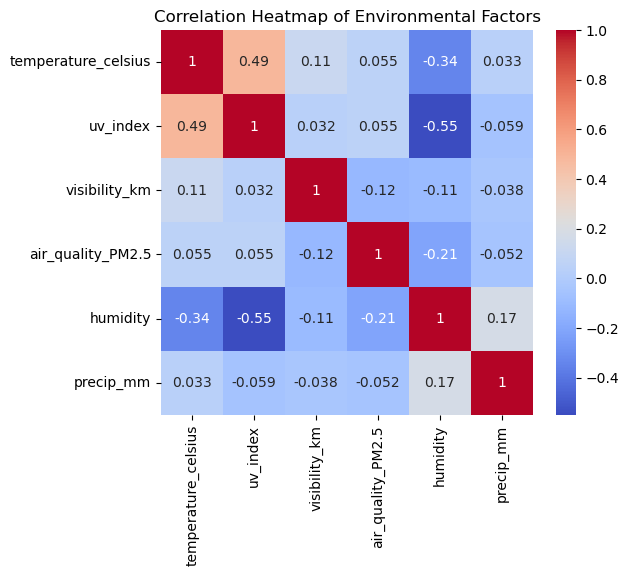

In [17]:
selected = df[[
    'temperature_celsius',
    'uv_index',
    'visibility_km',
    'air_quality_PM2.5',
    'humidity',
    'precip_mm'
]]

corr = selected.corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title('Correlation Heatmap of Environmental Factors')
plt.show()

- This heatmap shows how environmental factors like temperature, humidity, UV index, rainfall, and air pollution are related.
Values show whether the factors have a strong positive, negative, or weak relationship.


### Weather Factor Correlation Heatmap

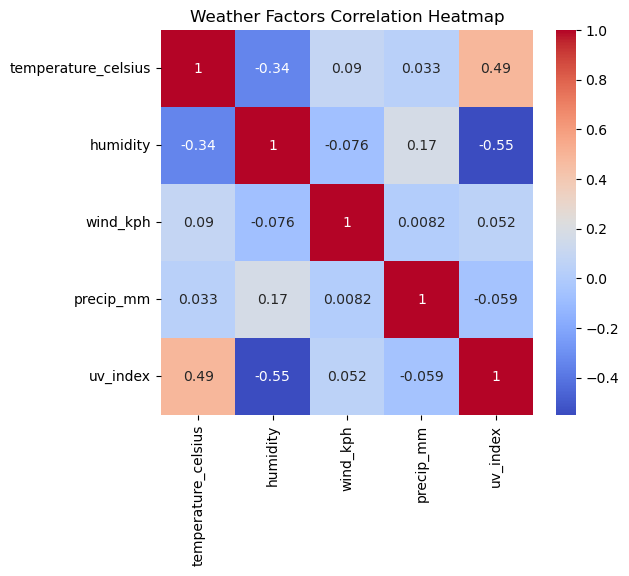

In [18]:
weather = df[[
    'temperature_celsius',
    'humidity',
    'wind_kph',
    'precip_mm',
    'uv_index'
]]

corr = weather.corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Weather Factors Correlation Heatmap")
plt.show()

- Temperature increases while humidity decreases, and it is positively related to the UV index.
- Humidity is negatively related to the UV index, meaning higher humidity gives lower UV values.
- Wind speed and precipitation show very weak relationships with the other factors.


### Air Pollution Correlation heatmap

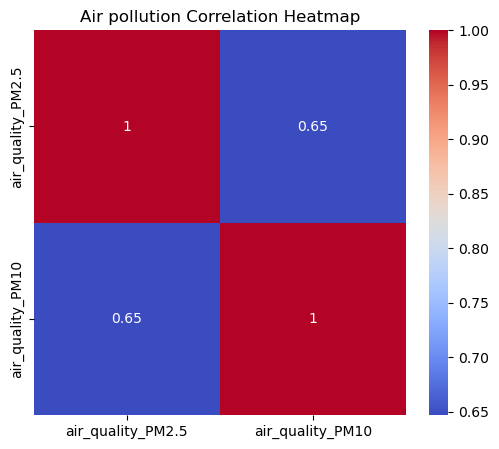

In [19]:
selected = df[['air_quality_PM2.5','air_quality_PM10']]

corr = selected.corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap='coolwarm')                                                                                                                                                                                                                                                            

plt.title('Air pollution Correlation Heatmap')                                                                                                   
plt.show()

- PM2.5 and PM10 show a strong positive correlation, meaning both increase or decrease together.
This indicates they come from similar pollution sources like dust, smoke, and vehicle emissions.


### Weather & Air Quality Correlation

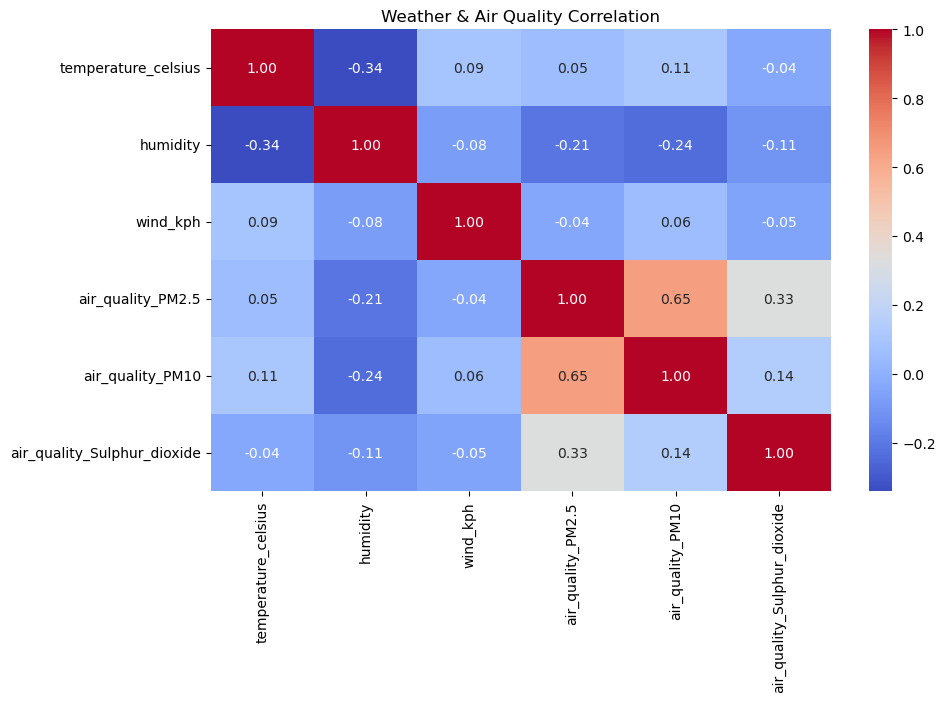

In [20]:
cols = [
    "temperature_celsius",
    "humidity",
    "wind_kph",
    "air_quality_PM2.5",
    "air_quality_PM10",
    "air_quality_Sulphur_dioxide"
]

corr = df[cols].corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Weather & Air Quality Correlation")
plt.show()

- Temperature, humidity, and wind show varying (mostly weak to moderate) relationships with air pollution levels.
Air pollutants (PM2.5, PM10, SO₂) tend to be more closely related to each other than to weather factors.


### Wind Speed Correlation Heatmap

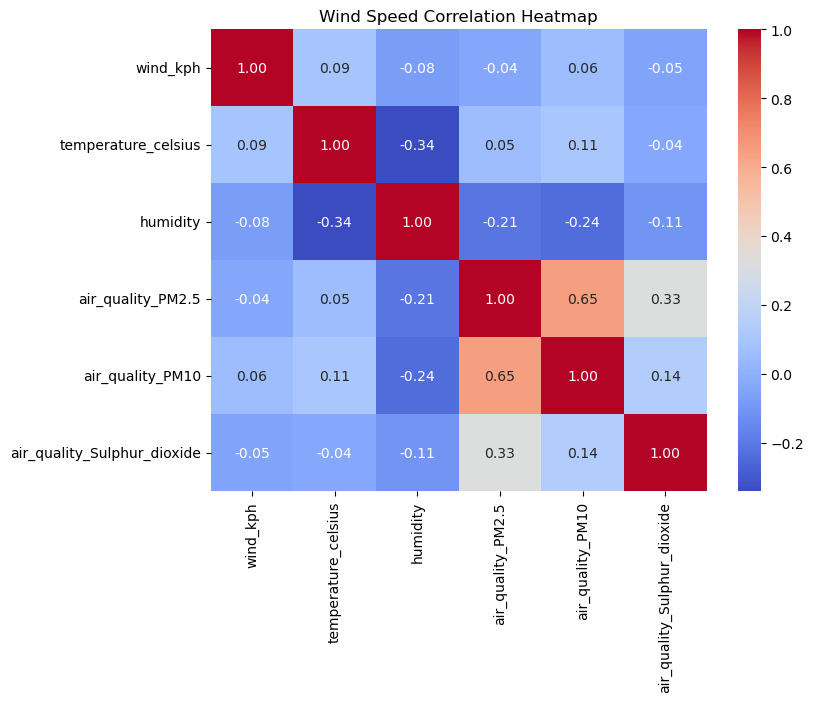

In [21]:
cols = [
    "wind_kph",
    "temperature_celsius",
    "humidity",
    "air_quality_PM2.5",
    "air_quality_PM10",
    "air_quality_Sulphur_dioxide"
]

selected = df[cols]

corr = selected.corr()

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Wind Speed Correlation Heatmap")
plt.show()

- Wind speed has weak to moderate correlation with temperature and humidity.
It shows low correlation with air pollution, meaning wind does not strongly affect pollution levels directly.


In [22]:
df

,country,location_name,latitude,longitude,timezone,last_updated,temperature_celsius,condition_text,wind_kph,wind_degree,...,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,year,month,hour,continent,city
0,Afghanistan,Kabul,34.5200,69.1800,Asia/Kabul,2024-05-16 13:15:00,26.6,Partly Cloudy,13.3,338,...,0.20,8.40,26.60,1,1,2024,5,13,Asia,Kabul
1,Albania,Tirana,41.3300,19.8200,Europe/Tirane,2024-05-16 10:45:00,19.0,Partly cloudy,11.2,320,...,0.10,1.10,2.00,1,1,2024,5,10,Europe,Tirane
2,Algeria,Algiers,36.7600,3.0500,Africa/Algiers,2024-05-16 09:45:00,23.0,Sunny,15.1,280,...,13.40,10.40,18.40,1,1,2024,5,9,Africa,Algiers
3,Andorra,Andorra La Vella,42.5000,1.5200,Europe/Andorra,2024-05-16 10:45:00,6.3,Light drizzle,11.9,215,...,0.20,0.70,0.90,1,1,2024,5,10,Europe,Andorra
4,Angola,Luanda,-8.8400,13.2300,Africa/Luanda,2024-05-16 09:45:00,26.0,Partly cloudy,13.0,150,...,31.50,183.40,262.30,5,10,2024,5,9,Africa,Luanda
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
135057,Venezuela,Caracas,10.5000,-66.9167,America/Caracas,2026-04-12 02:30:00,19.1,Partly Cloudy,3.6,178,...,2.35,16.35,18.15,2,2,2026,4,2,America,Caracas
135058,Vietnam,Hanoi,21.0333,105.8500,Asia/Bangkok,2026-04-12 13:30:00,34.2,Sunny,11.2,245,...,17.85,61.15,64.45,3,8,2026,4,13,Asia,Bangkok
135059,Yemen,Sanaa,15.3547,44.2067,Asia/Aden,2026-04-12 09:30:00,19.3,Sunny,6.5,217,...,1.35,7.45,15.35,1,1,2026,4,9,Asia,Aden
135060,Zambia,Lusaka,-15.4167,28.2833,Africa/Lusaka,2026-04-12 08:30:00,18.5,Sunny,13.7,90,...,1.85,5.45,6.15,1,1,2026,4,8,Africa,Lusaka
